# Compendio Integral de Machine Learning: Algoritmos Supervisados y No Supervisados

> Este laboratorio proporciona una visión estructurada, rigurosa y aplicada sobre los algoritmos fundamentales del aprendizaje automático, estructurados en dos bloques formativos:
1. **Aprendizaje Supervisado (*Supervised Learning*):**
   - **Modelos Lineales y Probabilísticos:** Regresión Logística y Regresión Lineal Múltiple.
   - **Modelos Basados en Distancias:** K-Nearest Neighbors (KNN).
   - **Modelos Basados en Fronteras de Margen Óptimo:** Máquinas de Vectores de Soporte (*Support Vector Machines - SVM*).
   - **Modelos de Árbol y Ensambles:**
     - Árboles de Decisión (*Decision Trees*).
     - Bosques Aleatorios (*Random Forest* - Enfoque Bagging).
     - Potenciación de Gradiente (*Gradient Boosting* y *XGBoost* - Enfoque Boosting).
   - **Modelos Bio-inspirados / Conexión profunda:** Redes Neuronales Artificiales (*Perceptrón Multicapa - MLP*).
2. **Aprendizaje No Supervisado (*Unsupervised Learning*):**
   - **Reducción de Dimensionalidad:** Análisis de Componentes Principales (PCA).
   - **Agrupamiento (*Clustering*):** K-Means, DBSCAN (detección de densidad y anomalías) y Clustering Jerárquico Aglomerativo (Ward linkage con Dendrograma).

Cada técnica cuenta con su justificación teórica en celdas Markdown en español, código comentado paso a paso y métricas directivas de evaluación.

> - Cargamos las bibliotecas científicas estándar para manipulación de matrices, estructuras de datos tabulares, visualización y modelado predictivo.

In [11]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
# Bibliotecas base del stack científico de Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# configuración de Seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

print("Bibliotecas de Python configuradas exitosamente.")

Bibliotecas de Python configuradas exitosamente.


---
# Sección 1: Aprendizaje Supervisado (*Supervised Learning*)

>- En el aprendizaje supervisado contamos con datos históricos conformados por una matriz de características predictoras $X \in \mathbb{R}^{n \times d}$ y un vector objetivo $y \in \mathbb{R}^n$. Nuestro objetivo es ajustar una función $f(X) \approx y$ que minimice el error de generalización sobre casos no observados.

### 1.1 Ingesta y Preparación del Dataset de Clasificación

>- Utilizamos el repositorio estructurado `Breast Cancer Wisconsin` (30 variables biométricas continuas, 569 observaciones) para resolver un problema de clasificación binaria (Diagnóstico: $0$ = Maligno, $1$ = Benigno). [Breast Cancer Wisconsin](https://www.kaggle.com/code/mragpavank/breast-cancer-wisconsin/input)

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Ingesta estructurada como DataFrame de Pandas
datos_cancer = load_breast_cancer(as_frame=True)
X_clf = datos_cancer.data
y_clf = datos_cancer.target
# Muestra las 30 variables predictoras junto con la columna 'target'
display(datos_cancer.frame.head())


# 2. Partición estratificada (80% Entrenamiento, 20% Prueba no observada)
# La estratificación preserva la proporción balanceada de casos en ambos subconjuntos
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

# 3. Estandarización de características (Media 0, Desviación 1)
# Crítico para algoritmos basados en distancias (KNN), márgenes (SVM) y optimizadores de gradiente (Redes Neuronales)
escalador_c = StandardScaler()
X_train_c_esc = escalador_c.fit_transform(X_train_c)
X_test_c_esc = escalador_c.transform(X_test_c)

print(f"Casos para entrenamiento: {X_train_c.shape[0]}")
print(f"Casos reservados para evaluación: {X_test_c.shape[0]}")
print(f"Categorías diagnósticas: {datos_cancer.target_names}")

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Casos para entrenamiento: 455
Casos reservados para evaluación: 114
Categorías diagnósticas: ['malignant' 'benign']


### 1.2 Fundamento Teórico de los Algoritmos de Clasificación

1. **Regresión Logística (*Logistic Regression*):** Modela la probabilidad logística mediante la función sigmoide $\sigma(z) = \frac{1}{1 + e^{-z}}$. Destaca por su alta interpretabilidad a través de sus coeficientes (*Odds Ratios*).
2. **K-Nearest Neighbors (*KNN*):** Algoritmo no paramétrico basado en vecindad geográfica. Asigna la clase mayoritaria de los $k$ vecinos más cercanos evaluando distancias euclidianas.
3. **Árboles de Decisión (*Decision Trees*):** Estructura jerárquica de partición del espacio mediante preguntas sucesivas que maximizan la pureza de los nodos (criterio Gini o Entropía). Es altamente intuitivo y transparente.
4. **Máquinas de Vectores de Soporte (*Support Vector Machines - SVM*):** Busca el hiperplano óptimo de decisión que maximiza la distancia (margen) entre las clases extremas (*vectores de soporte*). Emplea funciones *kernel* (como RBF) para proyectar datos no lineales a espacios de mayor dimensión.
5. **Random Forest (*Ensemble Bagging*):** Construye múltiples árboles de decisión descorrelacionados en paralelo y promedia sus votos para mitigar el sobreajuste y estabilizar la varianza.
6. **Gradient Boosting / XGBoost (*Ensemble Boosting*):** Entrena árboles de decisión de forma secuencial, donde cada nuevo árbol se enfoca en minimizar los errores residuales del árbol anterior utilizando el descenso de gradiente. Es el referente de la industria en datos tabulares.
7. **Red Neuronal Artificial (*Multi-Layer Perceptron - MLP*):** Arquitectura bio-inspirada compuesta por capas de neuronas interconectadas con funciones de activación no lineales (ReLU). Aprende representaciones abstractas mediante el algoritmo de retropropagación (*Backpropagation*).

In [13]:
# Importación de los algoritmos de clasificación requeridos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Verificamos si la biblioteca externa xgboost está disponible; de lo contrario se usa HistGradientBoosting
try:
    from xgboost import XGBClassifier
    modelo_xgboost = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric='logloss')
    nombre_xgb = "XGBoost (Extreme Gradient Boosting)"
except ImportError:
    modelo_xgboost = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42)
    nombre_xgb = "Gradient Boosting (HistGradientBoosting / XGBoost Fallback)"

# Diccionario con los 7 algoritmos de clasificación configurados
modelos_clasificacion = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Árbol de Decisión (Decision Tree)": DecisionTreeClassifier(max_depth=4, random_state=42),
    "SVM (Kernel RBF)": SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    "Random Forest (100 árboles)": RandomForestClassifier(n_estimators=100, random_state=42),
    nombre_xgb: modelo_xgboost,
    "Red Neuronal Sencilla (MLP: 64-32)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# Entrenamiento iterativo y cálculo de métricas en conjunto de prueba
reporte_clf = []

for nombre, modelo in modelos_clasificacion.items():
    # Ajuste del modelo sobre el conjunto de entrenamiento estandarizado
    modelo.fit(X_train_c_esc, y_train_c)
    
    # Inferencia predictiva sobre casos no observados
    y_pred = modelo.predict(X_test_c_esc)
    
    reporte_clf.append({
        "Algoritmo": nombre,
        "Exactitud (Accuracy)": f"{accuracy_score(y_test_c, y_pred):.2%}",
        "Precisión": f"{precision_score(y_test_c, y_pred):.2%}",
        "Exhaustividad (Recall)": f"{recall_score(y_test_c, y_pred):.2%}",
        "F1-Score": f"{f1_score(y_test_c, y_pred):.2%}"
    })

tabla_clf = pd.DataFrame(reporte_clf)
print("Comparación integral de algoritmos de clasificación (Test Set)")
display(tabla_clf)

Comparación integral de algoritmos de clasificación (Test Set)


,Algoritmo,Exactitud (Accuracy),Precisión,Exhaustividad (Recall),F1-Score
0,Regresión Logística,98.25%,98.61%,98.61%,98.61%
1,K-Nearest Neighbors (k=5),95.61%,95.89%,97.22%,96.55%
2,Árbol de Decisión (Decision Tree),93.86%,95.77%,94.44%,95.10%
3,SVM (Kernel RBF),98.25%,98.61%,98.61%,98.61%
4,Random Forest (100 árboles),95.61%,95.89%,97.22%,96.55%
5,Gradient Boosting (HistGradientBoosting / XGBo...,95.61%,94.67%,98.61%,96.60%
6,Red Neuronal Sencilla (MLP: 64-32),96.49%,98.57%,95.83%,97.18%


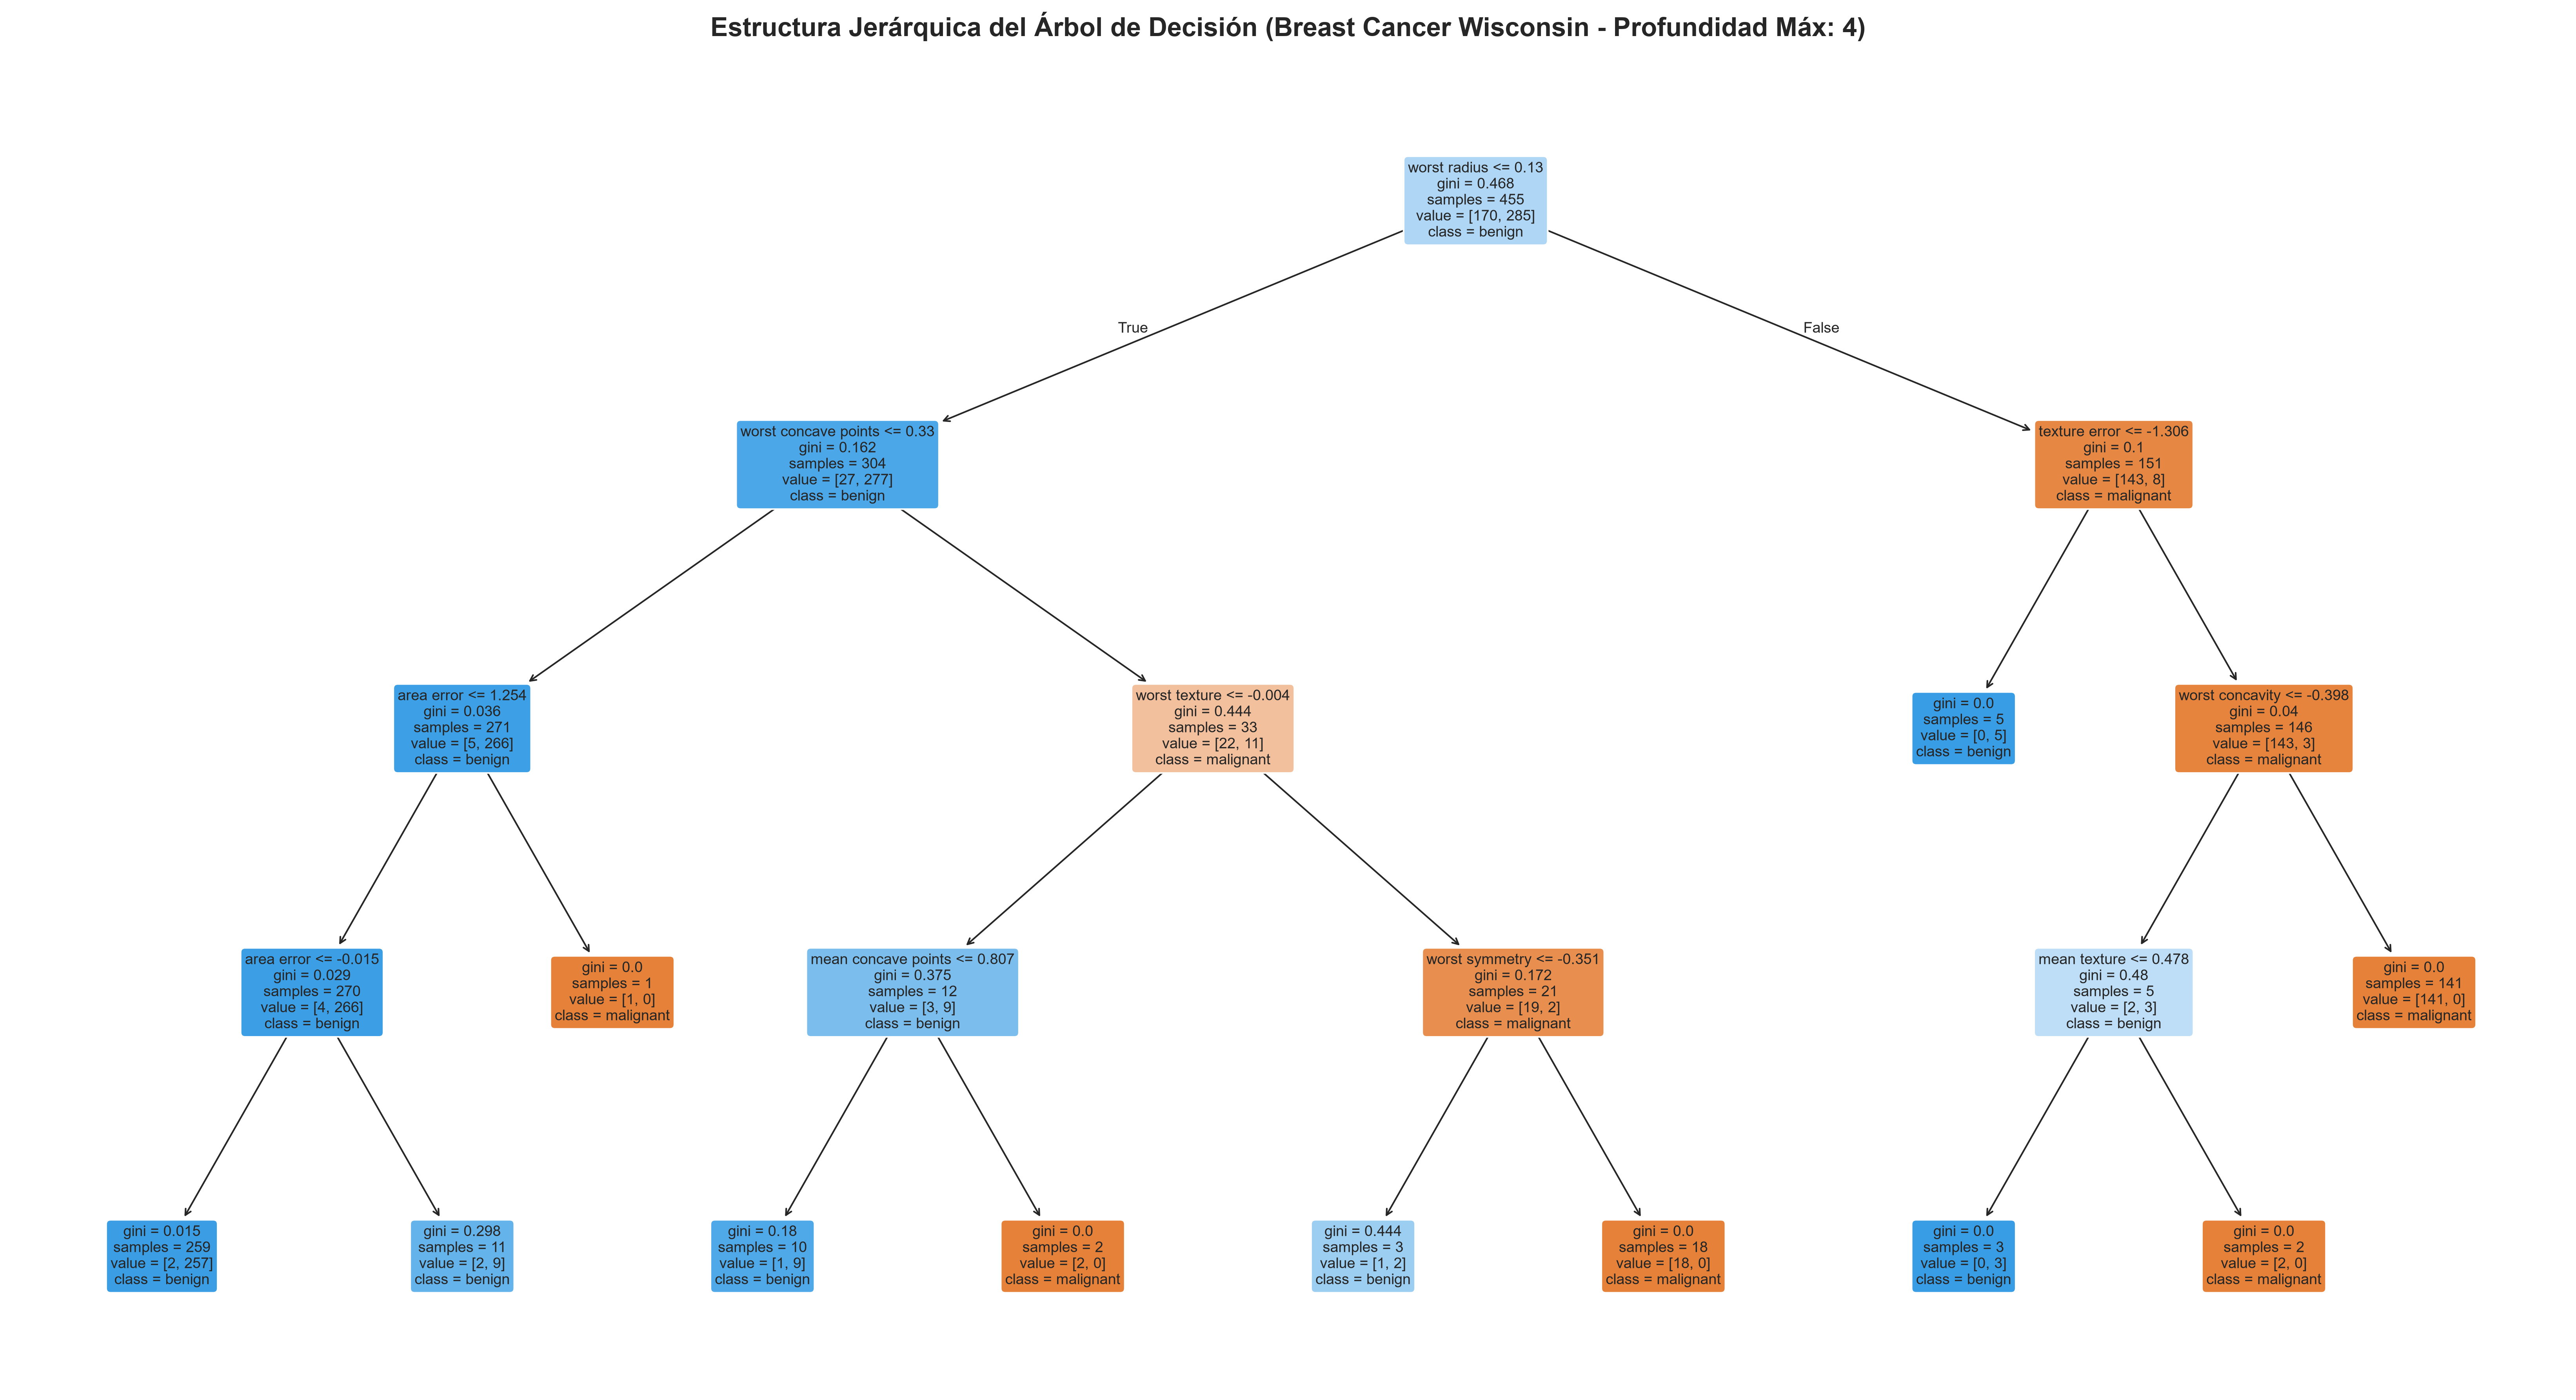

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Recuperamos el modelo de árbol ya entrenado del diccionario
modelo_arbol = modelos_clasificacion["Árbol de Decisión (Decision Tree)"]

# 2. Configuración del lienzo en alta resolución
plt.figure(figsize=(22, 12), dpi=300)

# 3. Renderizado del árbol de decisión
plot_tree(
    modelo_arbol,
    feature_names=list(datos_cancer.feature_names),
    class_names=list(datos_cancer.target_names),
    filled=True,              # Colorea los nodos según la clase dominante y pureza
    rounded=True,             # Bordes redondeados estéticos
    fontsize=9,
    impurity=True,            # Muestra el índice Gini en cada nodo
    proportion=False          # Muestra el número exacto de muestras
)

plt.title("Estructura Jerárquica del Árbol de Decisión (Breast Cancer Wisconsin - Profundidad Máx: 4)", 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


> - Informe de desempeño del clasificador de Regresiòn Logística para las clases Maligno y Benigno.

In [15]:
from sklearn.metrics import classification_report

# Inferencia con el modelo líder
y_pred_logreg = modelos_clasificacion["Regresión Logística"].predict(X_test_c_esc)

# Reporte formal desglosado por clase
print("Desglose diagnóstico por clase")
print(classification_report(
    y_test_c, 
    y_pred_logreg, 
    target_names=['Maligno (Clase 0)', 'Benigno (Clase 1)']
))


Desglose diagnóstico por clase
                   precision    recall  f1-score   support

Maligno (Clase 0)       0.98      0.98      0.98        42
Benigno (Clase 1)       0.99      0.99      0.99        72

         accuracy                           0.98       114
        macro avg       0.98      0.98      0.98       114
     weighted avg       0.98      0.98      0.98       114



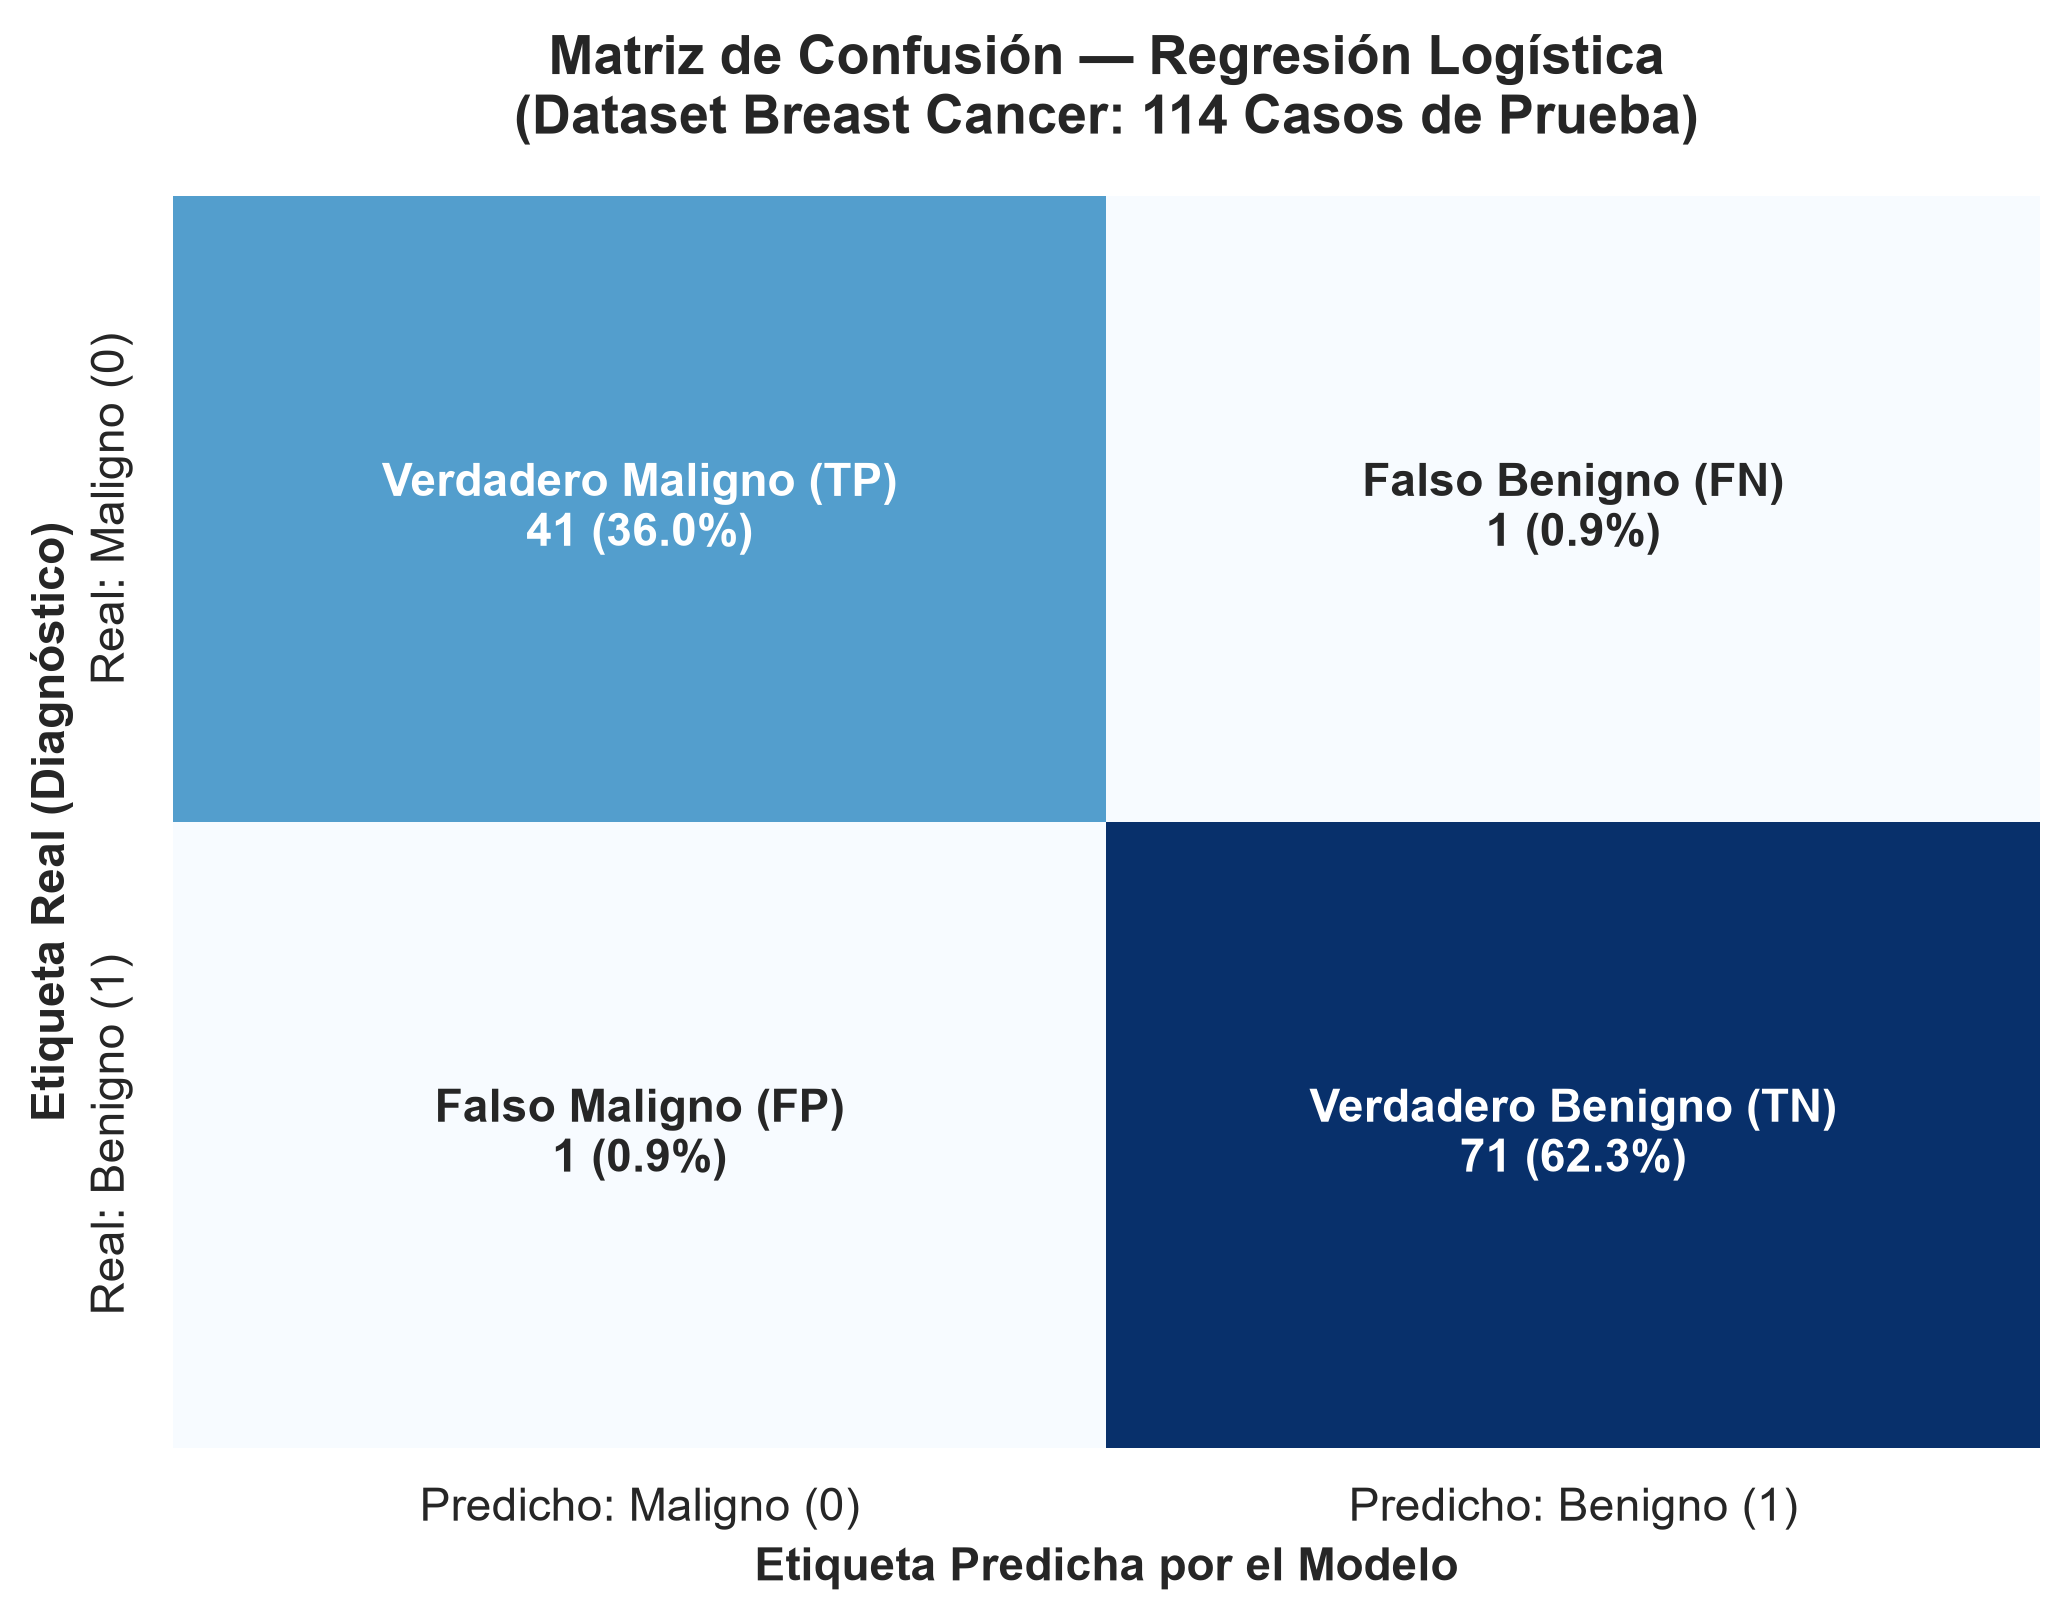

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Obtener las predicciones del modelo líder
modelo_elegido = modelos_clasificacion["Regresión Logística"]
y_pred = modelo_elegido.predict(X_test_c_esc)

# 2. Calcular la matriz de confusión
# Clases: 0 = Maligno, 1 = Benigno
cm = confusion_matrix(y_test_c, y_pred)

# 3. Formatear anotaciones con conteos y porcentajes
etiquetas_cuadrantes = [
    f"Verdadero Maligno (TP)\n{cm[0, 0]} ({cm[0, 0]/cm.sum():.1%})",
    f"Falso Benigno (FN)\n{cm[0, 1]} ({cm[0, 1]/cm.sum():.1%})",
    f"Falso Maligno (FP)\n{cm[1, 0]} ({cm[1, 0]/cm.sum():.1%})",
    f"Verdadero Benigno (TN)\n{cm[1, 1]} ({cm[1, 1]/cm.sum():.1%})"
]
etiquetas_cuadrantes = np.asarray(etiquetas_cuadrantes).reshape(2, 2)

# 4. Graficar la matriz
plt.figure(figsize=(7, 5.5), dpi=300)
sns.heatmap(
    cm, 
    annot=etiquetas_cuadrantes, 
    fmt="", 
    cmap="Blues", 
    cbar=False,
    xticklabels=['Predicho: Maligno (0)', 'Predicho: Benigno (1)'],
    yticklabels=['Real: Maligno (0)', 'Real: Benigno (1)'],
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title("Matriz de Confusión — Regresión Logística\n(Dataset Breast Cancer: 114 Casos de Prueba)", 
          fontsize=13, fontweight='bold', pad=15)
plt.ylabel("Etiqueta Real (Diagnóstico)", fontsize=11, fontweight='bold')
plt.xlabel("Etiqueta Predicha por el Modelo", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.3 Regresión Numérica Continua

>- **Problema:** Estimar un valor numérico cuantitativo continuo (valor medio de viviendas en cientos de miles de USD) utilizando el repositorio `California Housing`.

In [16]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

# Ingesta de datos de California Housing
california = fetch_california_housing(as_frame=True)
df_reg = california.frame.sample(n=2500, random_state=42)  # Muestra para agilidad en clase
X_reg = df_reg.drop(columns=['MedHouseVal'])
y_reg = df_reg['MedHouseVal']

# Partición de datos (80% Train, 20% Test)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.20, random_state=42)

# Modelos de Regresión
lin_reg = LinearRegression()
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

lin_reg.fit(X_tr_r, y_tr_r)
rf_reg.fit(X_tr_r, y_tr_r)

pred_lin = lin_reg.predict(X_te_r)
pred_rf = rf_reg.predict(X_te_r)

tabla_reg = pd.DataFrame([
    {
        "Algoritmo": "Regresión Lineal Múltiple",
        "R² Score (Capacidad Explicativa)": f"{r2_score(y_te_r, pred_lin):.2%}",
        "Margen de Error (RMSE)": f"{root_mean_squared_error(y_te_r, pred_lin):.4f}"
    },
    {
        "Algoritmo": "Random Forest Regressor",
        "R² Score (Capacidad Explicativa)": f"{r2_score(y_te_r, pred_rf):.2%}",
        "Margen de Error (RMSE)": f"{root_mean_squared_error(y_te_r, pred_rf):.4f}"
    }
])

print("Comparación de modelos de regresión continua")
display(tabla_reg)

Comparación de modelos de regresión continua


,Algoritmo,R² Score (Capacidad Explicativa),Margen de Error (RMSE)
0,Regresión Lineal Múltiple,59.77%,0.7199
1,Random Forest Regressor,73.68%,0.5823


---
# Sección 2: Aprendizaje No Supervisado (*Unsupervised Learning*)

>- En el aprendizaje no supervisado no disponemos de etiquetas objetivo $y$. El algoritmo explora la geometría, correlaciones y densidades latentes en la matriz de entrada $X$.

### 2.1 Reducción de Dimensionalidad: PCA (*Principal Component Analysis*)

>- Sintetiza la información de múltiples dimensiones correlacionadas proyectándola sobre componentes principales ortogonales no correlacionados, ordenados según la varianza explicada.

Varianza capturada por Componente 1: 44.41%
Varianza capturada por Componente 2: 18.94%
Información total conservada en el plano 2D: 63.36%


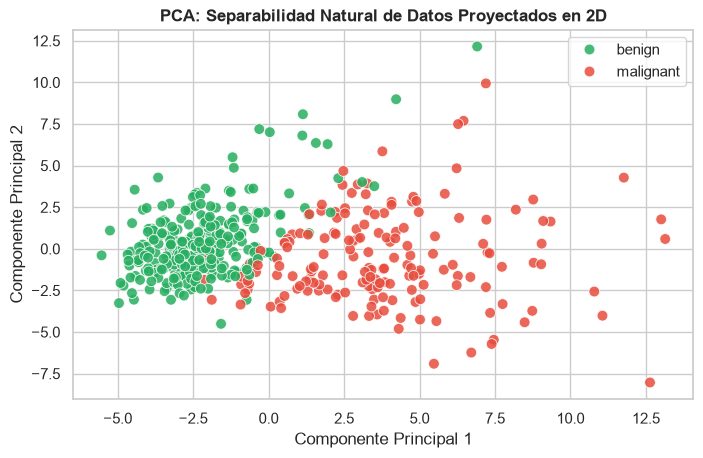

In [5]:
from sklearn.decomposition import PCA

# Proyección de las 30 variables continuas del dataset a 2 macrocomponentes principales
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_c_esc)

var_exp = pca.explained_variance_ratio_
print(f"Varianza capturada por Componente 1: {var_exp[0]:.2%}")
print(f"Varianza capturada por Componente 2: {var_exp[1]:.2%}")
print(f"Información total conservada en el plano 2D: {var_exp.sum():.2%}")

# Visualización de la proyección PCA
plt.figure(figsize=(8, 4.8))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=datos_cancer.target_names[y_train_c],
    palette={'malignant': '#e74c3c', 'benign': '#27ae60'},
    alpha=0.85, s=60
)
plt.title("PCA: Separabilidad Natural de Datos Proyectados en 2D", fontweight='bold')
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

### 2.2 Agrupamiento (*Clustering*): K-Means, DBSCAN y Clustering Jerárquico

> Comparamos los tres grandes paradigmas de agrupamiento sobre el espacio dimensional estandarizado:
- **K-Means:** Centroides y particiones esféricas.
- **DBSCAN:** Agrupamiento basado en densidad local con aislamiento de observaciones anómalas (etiqueta `-1`).
- **Clustering Jerárquico:** Enlace jerárquico aglomerativo estructurado mediante dendrograma.

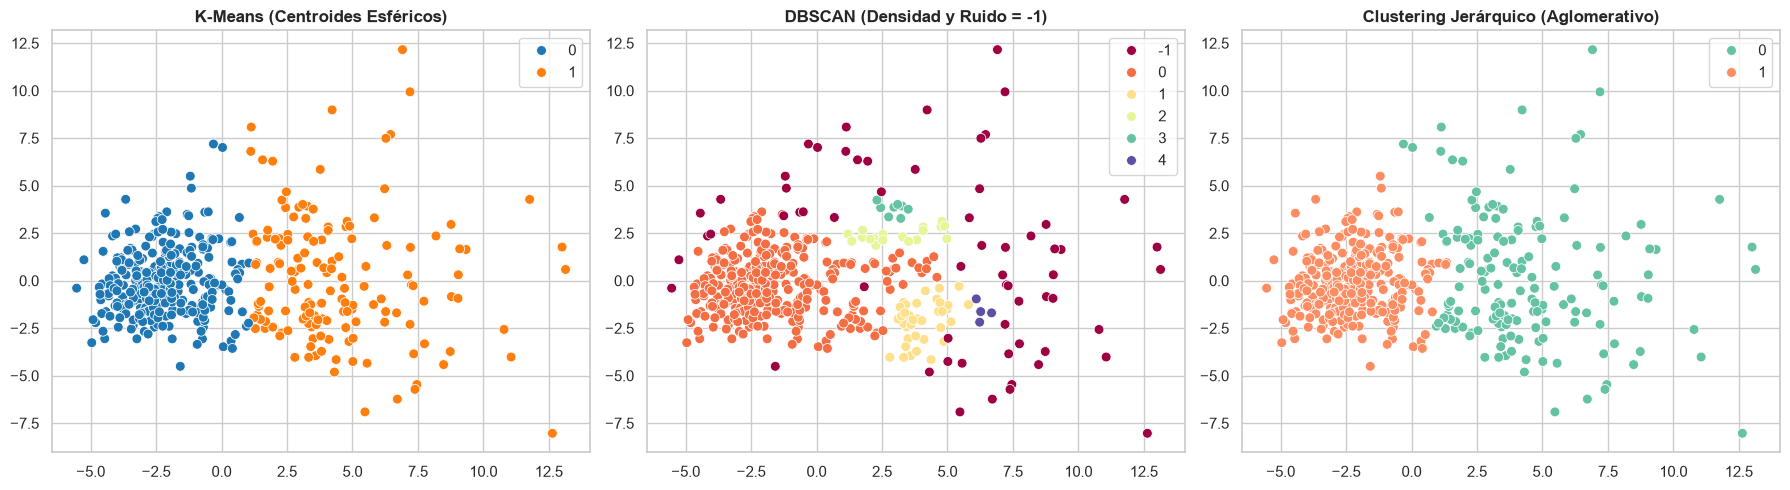

Silhouette Score K-Means:              0.5186
Silhouette Score Jerárquico:           0.5161
Silhouette Score DBSCAN (Sin outliers): 0.3675


In [6]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. K-Means (K=2)
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_pca)

# 2. DBSCAN (eps=0.8, min_samples=5)
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_db = dbscan.fit_predict(X_pca)

# 3. Jerárquico Aglomerativo (Ward)
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agg = agg.fit_predict(X_pca)

# Visualización comparativa de los tres métodos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_km, palette='tab10', ax=axes[0], s=50)
axes[0].set_title("K-Means (Centroides Esféricos)", fontweight='bold')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_db, palette='Spectral', ax=axes[1], s=50)
axes[1].set_title("DBSCAN (Densidad y Ruido = -1)", fontweight='bold')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_agg, palette='Set2', ax=axes[2], s=50)
axes[2].set_title("Clustering Jerárquico (Aglomerativo)", fontweight='bold')

plt.tight_layout()
plt.show()

# Auditoría de Cohesión y Separación con Silhouette Score
sil_km = silhouette_score(X_pca, labels_km)
sil_agg = silhouette_score(X_pca, labels_agg)
mask_db = labels_db != -1
sil_db = silhouette_score(X_pca[mask_db], labels_db[mask_db]) if len(np.unique(labels_db[mask_db])) > 1 else 0.0

print(f"Silhouette Score K-Means:              {sil_km:.4f}")
print(f"Silhouette Score Jerárquico:           {sil_agg:.4f}")
print(f"Silhouette Score DBSCAN (Sin outliers): {sil_db:.4f}")

### 2.3 Taxonomía Jerárquica: Dendrograma

> El dendrograma ilustra la secuencia de fusiones sucesivas entre grupos de clientes u observaciones. La altura del corte vertical permite definir niveles de decisión macro o tácticos.

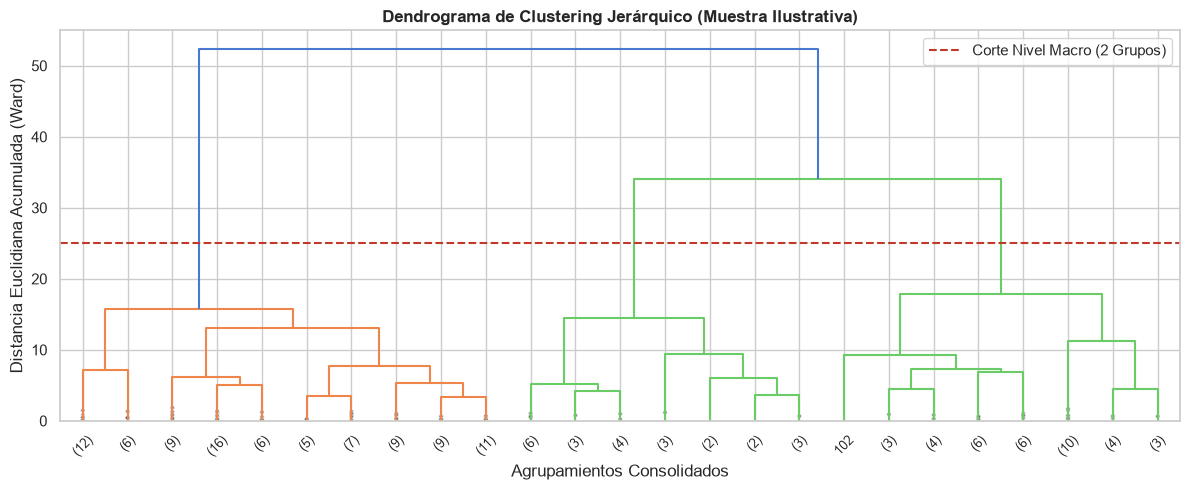

In [7]:
# Cálculo de matriz de distancias por enlaces de Ward (Muestra de 150 elementos para claridad visual)
enlaces_ward = linkage(X_pca[:150], method='ward')

plt.figure(figsize=(12, 5))
dendrogram(enlaces_ward, truncate_mode='lastp', p=25, leaf_rotation=45, leaf_font_size=9, show_contracted=True)
plt.title("Dendrograma de Clustering Jerárquico (Muestra Ilustrativa)", fontweight='bold')
plt.xlabel("Agrupamientos Consolidados")
plt.ylabel("Distancia Euclidiana Acumulada (Ward)")
plt.axhline(y=25, color='#c0392b', linestyle='--', label='Corte Nivel Macro (2 Grupos)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 3. Matriz comparativa de Algoritmos

| Paradigma | Algoritmo | Familia Metodológica | Fortalezas Principales | Puntos de Atención / Limitaciones |
|---|---|---|---|---|
| **Supervisado** | **Regresión Logística** | Modelo Lineal Probabilístico | Rápido, interpretable mediante *Odds Ratios*, calibración de probabilidades. | Asume separabilidad lineal entre clases. |
| **Supervisado** | **KNN** | Basado en Distancias (Instancias) | Sin suposiciones paramétricas; altamente intuitivo. | Alto costo en inferencia ($\mathcal{O}(N)$); sensible al escalamiento. |
| **Supervisado** | **Decision Tree** | Árboles de Partición | Reglas transparentes ("si-entonces"); interpretable directamente. | Propenso al sobreajuste si no se poda la profundidad (`max_depth`). |
| **Supervisado** | **SVM** | Margen Óptimo de Hiperplano | Efectivo en espacios de alta dimensión; robusto frente a sobreajuste. | Costoso en conjuntos de datos masivos; sensible a la elección del *kernel*. |
| **Supervisado** | **Random Forest** | Ensamble Bagging (Paralelo) | Captura no-linealidades complejas; gran resistencia al ruido y sobreajuste. | Mayor consumo de memoria; pierde la interpretabilidad de un árbol único. |
| **Supervisado** | **Gradient Boosting / XGBoost** | Ensamble Boosting (Secuencial) | Precisión estado del arte en datos tabulares; optimización adaptativa del error. | Mayor tiempo de calibración; requiere afinamiento de hiperparámetros. |
| **Supervisado** | **Red Neuronal (MLP)** | Redes Neuronales Artificiales | Capacidad de aproximación universal; modela patrones no lineales complejos. | Requiere estandarización estricta; mayor tiempo de cómputo y riesgo de mínimos locales. |
| **Supervisado** | **Regresión Lineal** | Modelo Lineal Continuo | Solución matemática cerrada; métricas financieras directas ($R^2$, RMSE). | Vulnerable a valores extremos y supuestos de homocedasticidad. |
| **No Supervisado** | **PCA** | Transformación Lineal Ortogonal | Maximiza la varianza retenida y elimina redundancia/multicolinealidad. | Los componentes generados son combinaciones abstractas de difícil lectura física. |
| **No Supervisado** | **K-Means** | Particional por Centroides | Complejidad lineal $\mathcal{O}(N)$; centroides interpretables en producción. | Requiere predefinir $K$; asume agrupaciones con forma esférica. |
| **No Supervisado** | **DBSCAN** | Basado en Densidad Espacial | Identifica formas complejas; aísla automáticamente anomalías y ruido ($-1$). | Sensible a la elección de `eps` y `min_samples` ante densidades dispares. |
| **No Supervisado** | **Jerárquico** | Aglomerativo (Ward) | Revela taxonomías en dendrograma; no exige prefijar $K$ al inicio. | Complejidad cuadrática $\mathcal{O}(N^2)$ inviable para big data transaccional. |